<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/Gradient_boosting_for_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [6]:
X = np.random.rand(100,1) - 0.5


In [7]:
y = 3*X[:,0]**2 + 0.05 * np.random.randn(100)

In [8]:
import pandas as pd
df = pd.DataFrame()

In [9]:
df['X'] = X.reshape(100)
df['y'] = y

Text(0.5, 1.0, 'X vs y')

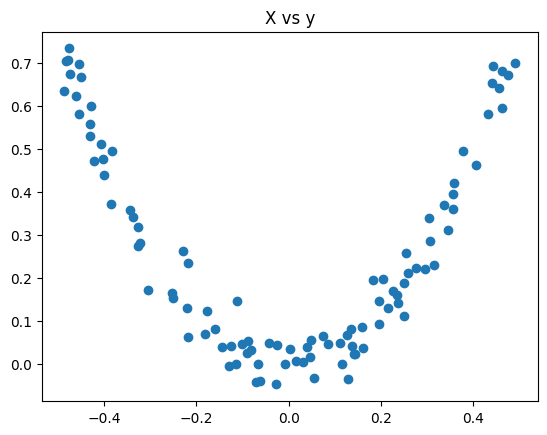

In [10]:
plt.scatter(df['X'],df['y'])
plt.title('X vs y')

In [11]:
df['pred1'] = df['y'].mean()

In [12]:
df

,X,y,pred1
0,-0.448318,0.668242,0.257921
1,0.031355,0.004000,0.257921
2,0.040635,0.039051,0.257921
3,0.137430,0.041148,0.257921
4,0.226091,0.169560,0.257921
...,...,...,...
95,0.430757,0.582378,0.257921
96,0.358413,0.420960,0.257921
97,-0.071006,-0.041107,0.257921
98,0.250871,0.112103,0.257921


In [13]:
df['res1']=df['y'] - df['pred1']

In [14]:
df

,X,y,pred1,res1
0,-0.448318,0.668242,0.257921,0.410320
1,0.031355,0.004000,0.257921,-0.253922
2,0.040635,0.039051,0.257921,-0.218870
3,0.137430,0.041148,0.257921,-0.216774
4,0.226091,0.169560,0.257921,-0.088361
...,...,...,...,...
95,0.430757,0.582378,0.257921,0.324456
96,0.358413,0.420960,0.257921,0.163038
97,-0.071006,-0.041107,0.257921,-0.299028
98,0.250871,0.112103,0.257921,-0.145818


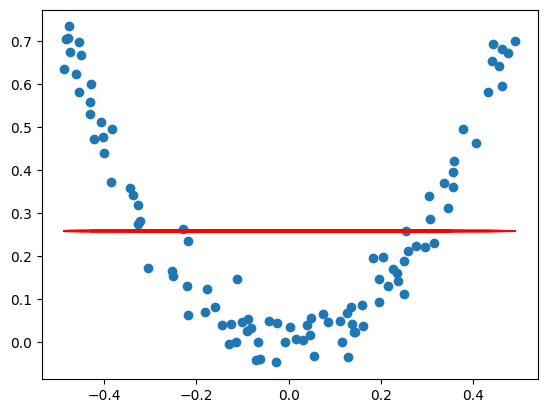

In [15]:

plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')

In [16]:
from sklearn.tree import DecisionTreeRegressor

In [17]:
tree1 = DecisionTreeRegressor(max_leaf_nodes= 8)
tree1.fit(df['X'].values.reshape(100,1), df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

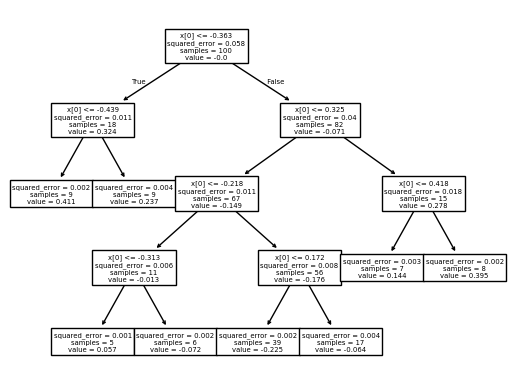

In [18]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [19]:
# generate X_test
X_test = np.linspace(-0.5,0.5,500)
y_pred = 0.265458 + tree1.predict(X_test.reshape(500,1))

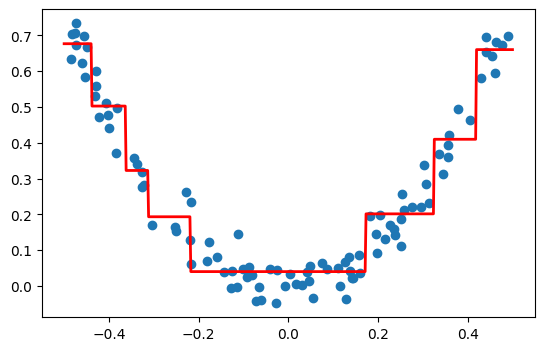

In [20]:

plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

In [21]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [22]:
df

,X,y,pred1,res1,pred2
0,-0.448318,0.668242,0.257921,0.410320,0.676707
1,0.031355,0.004000,0.257921,-0.253922,0.040432
2,0.040635,0.039051,0.257921,-0.218870,0.040432
3,0.137430,0.041148,0.257921,-0.216774,0.040432
4,0.226091,0.169560,0.257921,-0.088361,0.201661
...,...,...,...,...,...
95,0.430757,0.582378,0.257921,0.324456,0.660256
96,0.358413,0.420960,0.257921,0.163038,0.409910
97,-0.071006,-0.041107,0.257921,-0.299028,0.040432
98,0.250871,0.112103,0.257921,-0.145818,0.201661


In [23]:
df['res2'] = df['y'] - df['pred2']
df

,X,y,pred1,res1,pred2,res2
0,-0.448318,0.668242,0.257921,0.410320,0.676707,-0.008465
1,0.031355,0.004000,0.257921,-0.253922,0.040432,-0.036433
2,0.040635,0.039051,0.257921,-0.218870,0.040432,-0.001381
3,0.137430,0.041148,0.257921,-0.216774,0.040432,0.000715
4,0.226091,0.169560,0.257921,-0.088361,0.201661,-0.032101
...,...,...,...,...,...,...
95,0.430757,0.582378,0.257921,0.324456,0.660256,-0.077879
96,0.358413,0.420960,0.257921,0.163038,0.409910,0.011050
97,-0.071006,-0.041107,0.257921,-0.299028,0.040432,-0.081539
98,0.250871,0.112103,0.257921,-0.145818,0.201661,-0.089558


In [24]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)


DecisionTreeRegressor(max_leaf_nodes=8)

In [29]:
y_pred = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])


Text(0.5, 1.0, 'X vs y')

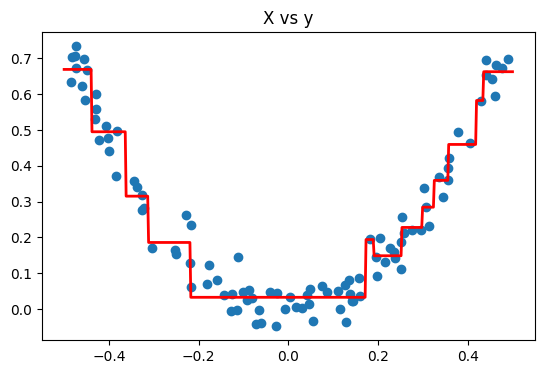

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')